In [5]:
# import librairies
## data
import pandas as pd
import numpy as np

## ML (preprocessing --> transformation --> regression)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import Pipeline

## Plot
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [ ]:
def get_all_models_score(X_train,X_test,y_train,y_test):
    # ================================
    '''01 - Linear'''
    # ================================
    Input=[('scale',StandardScaler()),('Model',LinearRegression())]
    lm=LinearRegression()
    pipe_lm=Pipeline(Input)

    # Std
    pipe_lm.fit(X_train,y_train)
    lm_score_train=pipe_lm.score(X_train,y_train)
    lm_score_test=pipe_lm.score(X_test,y_test)

    # NoStd
    lm.fit(X_train,y_train)
    lm_score_nostd_train=lm.score(X_train,y_train)
    lm_score_nostd_test=lm.score(X_test,y_test)

    print(f'Linear :\ntrain_R^2={lm_score_train};test_R^2={lm_score_test}')
    print(f'No StdScaler : train_R^2={lm_score_nostd_train};test_R^2={lm_score_nostd_test}')
    print("")

    # ================================
    '''02 - Polynomial'''
    # ================================
    for scaler in ["Std Scaler:","No Std Scaler:"]:
        print(f'Polynomial - {scaler}')
        if scaler=='Std Scaler:':
            list_pol_score=[]
            for degree in range(2,3):
                Input=[('polynomial',PolynomialFeatures(degree=degree)),('scale',StandardScaler()),('Model',LinearRegression())]
                pipe_pol=Pipeline(Input)
                pipe_pol.fit(X_train,y_train)
                pol_score_train=pipe_pol.score(X_train,y_train)
                pol_score_test=pipe_pol.score(X_test,y_test)
                list_pol_score.append(pol_score_test)
                print(f'with degree={degree}, train_R^2={pol_score_train};test_R^2={pol_score_test}')
            print('')
        else:
            list_pol_score_nostd=[]
            for degree in range(2,3):
                Input=[('polynomial',PolynomialFeatures(degree=degree)),('Model',LinearRegression())]
                pol=Pipeline(Input)
                pol.fit(X_train,y_train)
                pol_score_nostd_train=pol.score(X_train,y_train)
                pol_score_nostd_test=pol.score(X_test,y_test)
                list_pol_score_nostd.append(pol_score_nostd_test)
                print(f'with degree={degree},train_R^2={pol_score_nostd_train},test_R^2={pol_score_nostd_test}')
    print('')

    # ================================
    '''03 - Ridge'''
    # ================================
    list_ridge_score_std=[]
    list_ridge_score_nostd=[]
    for scaler in ["Std Scaler:","No Std Scaler:"]:
        print(f'Ridge - {scaler}')
        for exp in range(-5,4):
            alpha=10**exp
            if scaler=='Std Scaler:':
                Input=[('polynomial',PolynomialFeatures(degree=2)),('scale',StandardScaler()),('Model',Ridge(alpha=alpha))]
                pipe_ridge=Pipeline(Input)
                pipe_ridge.fit(X_train,y_train)
                rid_score_train=pipe_ridge.score(X_train,y_train)
                rid_score_test=pipe_ridge.score(X_test,y_test)
                list_ridge_score_std.append(rid_score_test)
                print(f'with alpha={alpha},train_R^2={rid_score_train};test_R^2={rid_score_test}')
            else:
                Input=[('polynomial',PolynomialFeatures(degree=2)),('Model',Ridge(alpha=alpha))]
                pipe_ridge=Pipeline(Input)
                pipe_ridge.fit(X_train,y_train)
                rid_score_nostd_train=pipe_ridge.score(X_train,y_train)
                rid_score_nostd_test=pipe_ridge.score(X_test,y_test)
                list_ridge_score_nostd.append(rid_score_nostd_test)
                print(f'with alpha={alpha},train_R^2={rid_score_nostd_train};test_R^2={rid_score_nostd_test}')
    # ===============================
    '''04 - Plot Scores'''
    scores_dict={'lm_score_std':lm_score_test,'lm_score_nostd':lm_score_nostd_test,'pol_score_std':max(list_pol_score),'pol_score_nostd':max(list_pol_score_nostd),"ridge_score_std":max(list_ridge_score_std),"ridge_score_nostd":max(list_ridge_score_nostd)}
    values = list(scores_dict.values())
    norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
    colors = [cm.RdYlGn(norm(v)) for v in values]
    plt.bar(scores_dict.keys(), scores_dict.values(), color=colors)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('R²')
    plt.title('Model scores comparison')
    plt.tight_layout()
    plt.show()


In [ ]:
# 01.0 - Load Dataset
def load_dataset(path):
    df=pd.read_csv(path)
    return df

# 01.1  - Remove columns and outliers
def clean_columns(df):
    # Remove cols
    for column in ['url','zip_code','city','price_sqm','type_of_sale','furnished','fully_equipped_kitchen','surface_of_the_land','open_fire']:
        try:
            df=df.drop(column,axis=1)
        except:
            pass
    return df
#       - Clean outliers
def clean_outliers(df,whisker=3):
    cols_to_clean=df[['price','number_of_rooms','living_area']]
    # Remove outliers (3*IQR = soft removing >< 1.5*IQR)
    ## Get quartiles
    Q1=cols_to_clean.quantile(0.25)
    Q3=cols_to_clean.quantile(0.75)
    IQR=Q3-Q1
    ## Get limits
    low_limit=(Q1-whisker*IQR).clip(lower=0)
    high_limit=Q3+whisker*IQR

    ### Find limit value for 'Garden area' for prop with garden
    prop_with_garden=(df[df['garden_area']>0]==True).index
    prop_with_garden=df.loc[prop_with_garden]
    gardenQ1=prop_with_garden['garden_area'].quantile(0.25)
    gardenQ3=prop_with_garden['garden_area'].quantile(0.75)
    gardenIQR=gardenQ3-gardenQ1
    garden_high_limit=gardenQ3+whisker*gardenIQR

    ### Change limit in high_limit
    high_limit['garden_area']=garden_high_limit
    high_limit

    ## Exclude outliers
    ### Create SubDataSet with replaced NaN values
    sub_excl_manip=df
    sub_excl_manip=sub_excl_manip.replace(np.nan,0)
    cols_to_clean_names=cols_to_clean.columns
    mask=sub_excl_manip[cols_to_clean_names].apply(lambda x: x.between(low_limit[x.name],high_limit[x.name])).all(axis=1)

    ### Retrieve Dataset without outliers
    df=df[mask]

    return df

# 01.2 - Get target and features
def get_X_y(df):
    X=df.drop(['price'],axis=1)
    y=df['price']
    return X,y

# 02.0 - Replace missing values
def clean_data(X):

    num_col=X.select_dtypes(['float64','int64']).columns
    if 'garden' in X.columns:
        median_garden = X.loc[X['garden'] == 1, 'garden_area'].median()
        X['garden_area']=X['garden_area'].fillna(median_garden)
        num_col=num_col.drop(['garden_area'])
    X[num_col]=X[num_col].fillna(X[num_col].median())
    return X

# 02.1 - Split into train and test and process cleaning
def split_clean_data(X,y,test_size=0.2,random_state=42):

    X=pd.get_dummies(X)
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=test_size,random_state=random_state)

    # 03 - Clean data & check dtypes & convert into 'int'
    X_train=clean_data(X_train)
    X_test=clean_data(X_test)
    if (X_train.dtypes == X_test.dtypes).all() and (y_train.dtype == y_test.dtype):
        print('Data is OK')
        X_train=X_train.astype('int')
        X_test=X_test.astype('int')
        y_train=y_train.astype('int')
        y_test=y_test.astype('int')
    else: print ('Data types are differents')
    return X_train,X_test,y_train,y_test

In [43]:
# 03 - Get models
def get_all_models_score(X_train,X_test,y_train,y_test):
    # ================================
    '''01 - Linear'''
    # ================================
    Input=[('scale',StandardScaler()),('Model',LinearRegression())]
    lm=LinearRegression()
    pipe_lm=Pipeline(Input)

    # Std
    pipe_lm.fit(X_train,y_train)
    lm_score_train=pipe_lm.score(X_train,y_train)
    lm_score_test=pipe_lm.score(X_test,y_test)

    # NoStd
    lm.fit(X_train,y_train)
    lm_score_nostd_train=lm.score(X_train,y_train)
    lm_score_nostd_test=lm.score(X_test,y_test)

#    print(f'Linear :\ntrain_R^2={lm_score_train};test_R^2={lm_score_test}')
#    print(f'No StdScaler : train_R^2={lm_score_nostd_train};test_R^2={lm_score_nostd_test}')
#   print("")

    # ================================
    '''02 - Polynomial'''
    # ================================
    for scaler in ["Std Scaler:","No Std Scaler:"]:
#        print(f'Polynomial - {scaler}')
        if scaler=='Std Scaler:':
            list_pol_score=[]
            for degree in range(2,3):
                Input=[('polynomial',PolynomialFeatures(degree=degree)),('scale',StandardScaler()),('Model',LinearRegression())]
                pipe_pol=Pipeline(Input)
                pipe_pol.fit(X_train,y_train)
                pol_score_train=pipe_pol.score(X_train,y_train)
                pol_score_test=pipe_pol.score(X_test,y_test)
                list_pol_score.append(pol_score_test)
#                print(f'with degree={degree}, train_R^2={pol_score_train};test_R^2={pol_score_test}')
#            print('')
        else:
            list_pol_score_nostd=[]
            for degree in range(2,3):
                Input=[('polynomial',PolynomialFeatures(degree=degree)),('Model',LinearRegression())]
                pol=Pipeline(Input)
                pol.fit(X_train,y_train)
                pol_score_nostd_train=pol.score(X_train,y_train)
                pol_score_nostd_test=pol.score(X_test,y_test)
                list_pol_score_nostd.append(pol_score_nostd_test)
#                print(f'with degree={degree},train_R^2={pol_score_nostd_train},test_R^2={pol_score_nostd_test}')
#    print('')

    # ================================
    '''03 - Ridge'''
    # ================================
    list_ridge_score_std=[]
    list_ridge_score_nostd=[]
    for scaler in ["Std Scaler:","No Std Scaler:"]:
#        print(f'Ridge - {scaler}')
        for exp in range(-5,4):
            alpha=10**exp
            if scaler=='Std Scaler:':
                Input=[('polynomial',PolynomialFeatures(degree=2)),('scale',StandardScaler()),('Model',Ridge(alpha=alpha))]
                pipe_ridge=Pipeline(Input)
                pipe_ridge.fit(X_train,y_train)
                rid_score_train=pipe_ridge.score(X_train,y_train)
                rid_score_test=pipe_ridge.score(X_test,y_test)
                list_ridge_score_std.append(rid_score_test)
#                print(f'with alpha={alpha},train_R^2={rid_score_train};test_R^2={rid_score_test}')
            else:
                Input=[('polynomial',PolynomialFeatures(degree=2)),('Model',Ridge(alpha=alpha))]
                pipe_ridge=Pipeline(Input)
                pipe_ridge.fit(X_train,y_train)
                rid_score_nostd_train=pipe_ridge.score(X_train,y_train)
                rid_score_nostd_test=pipe_ridge.score(X_test,y_test)
                list_ridge_score_nostd.append(rid_score_nostd_test)
#                print(f'with alpha={alpha},train_R^2={rid_score_nostd_train};test_R^2={rid_score_nostd_test}')
    # ===============================
    '''04 - Plot Scores'''
    scores_dict={'lm_score_std':lm_score_test,'lm_score_nostd':lm_score_nostd_test,'pol_score_std':max(list_pol_score),'pol_score_nostd':max(list_pol_score_nostd),"ridge_score_std":max(list_ridge_score_std),"ridge_score_nostd":max(list_ridge_score_nostd)}
    values = list(scores_dict.values())
    norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
    colors = [cm.RdYlGn(norm(v)) for v in values]
    plt.bar(scores_dict.keys(), scores_dict.values(), color=colors)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('R²')
    plt.title('Model scores comparison')
    plt.tight_layout()
    plt.show()

    for k,v in scores_dict.items():
        if v==max(scores_dict.values()):
            print(f'best model: {k}, with score = {v}')


————————————————————
with outliers inside 1.5*IQR
————————————————————
————————————————————
Test number 0 : test_size = 0.1
subtest 0
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.450991893379316e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3250226917071581e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3195450699096959e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

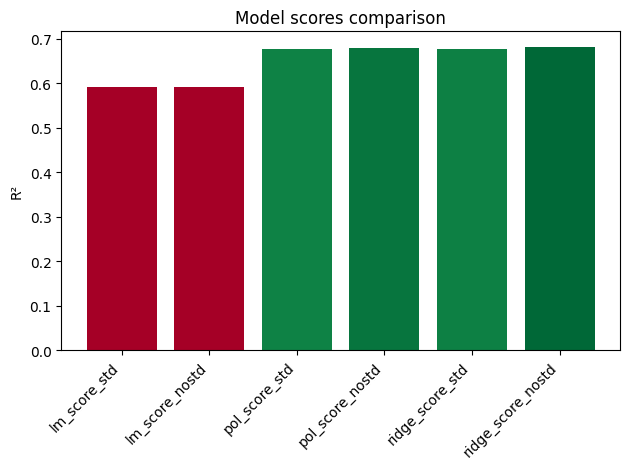

best model: ridge_score_nostd, with score = 0.6822794179870842
subtest 1
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2950710680494955e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2946652723284819e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2897926244942514e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

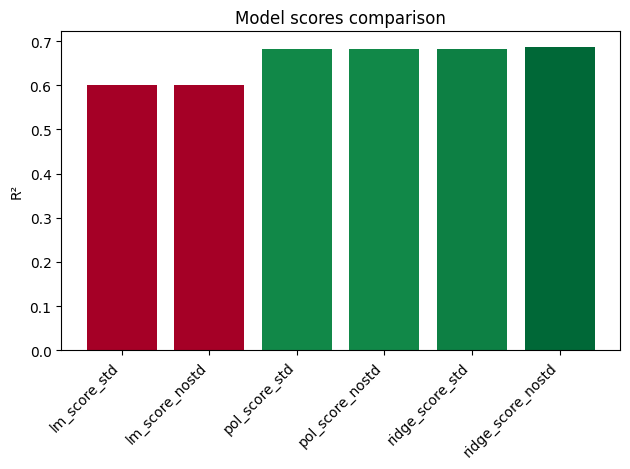

best model: ridge_score_nostd, with score = 0.6876618097445326
subtest 2
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.295314172983386e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2949657686606642e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2907129888690297e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

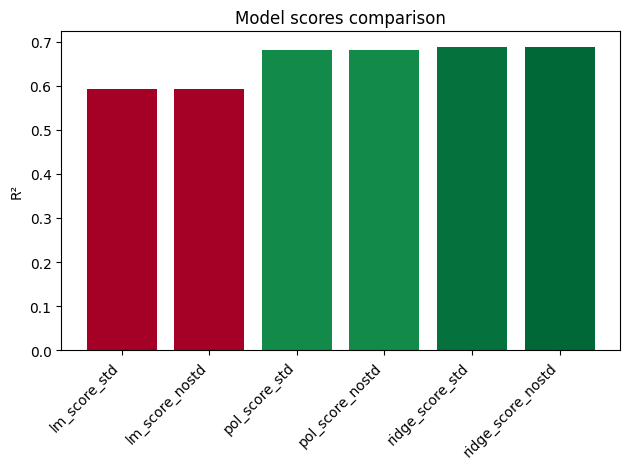

best model: ridge_score_nostd, with score = 0.6887425541333496
subtest 3
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.296024537189005e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2956442298513136e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2908498419706832e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

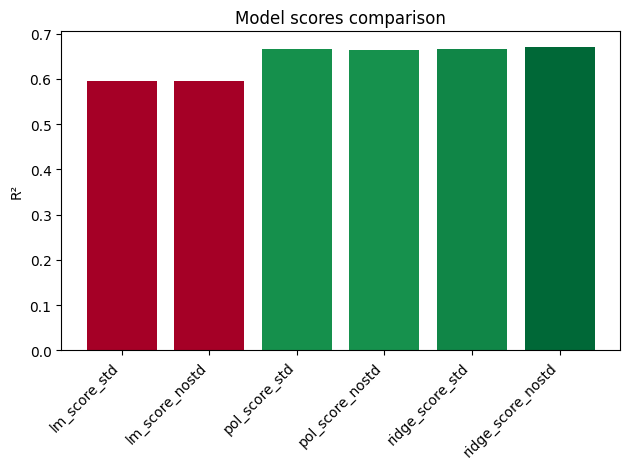

best model: ridge_score_nostd, with score = 0.6715424106853298
————————————————————
Test number 1 : test_size = 0.2
subtest 0
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1988270713174274e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3194693621348588e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3234556823422993e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

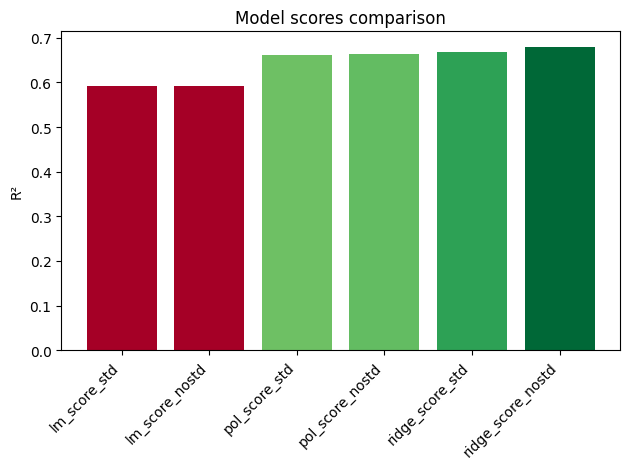

best model: ridge_score_nostd, with score = 0.6803896700900123
subtest 1
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.496519155540556e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3044688843137826e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2980468244248858e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

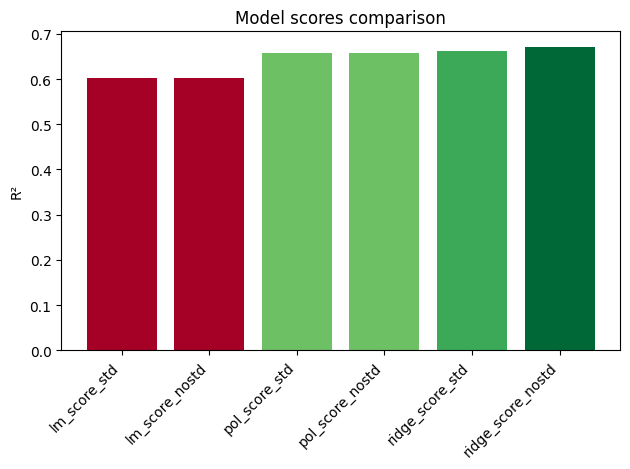

best model: ridge_score_nostd, with score = 0.6719116535441658
subtest 2
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.083041285405282e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.207941609310935e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.1831852311826265e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco

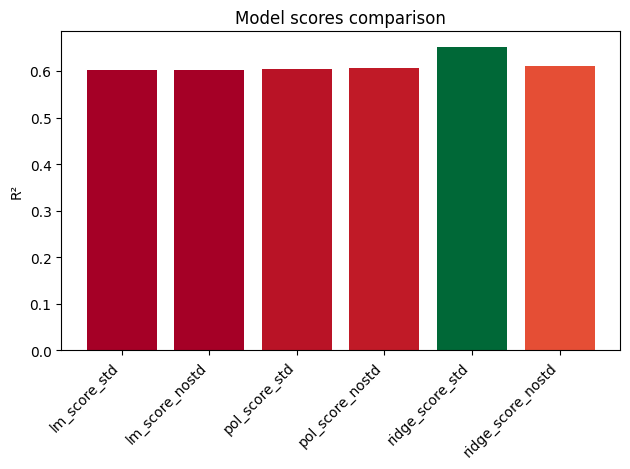

best model: ridge_score_std, with score = 0.6525173558340163
subtest 3
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.619214269634107e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5840150987973135e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5767476353290625e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

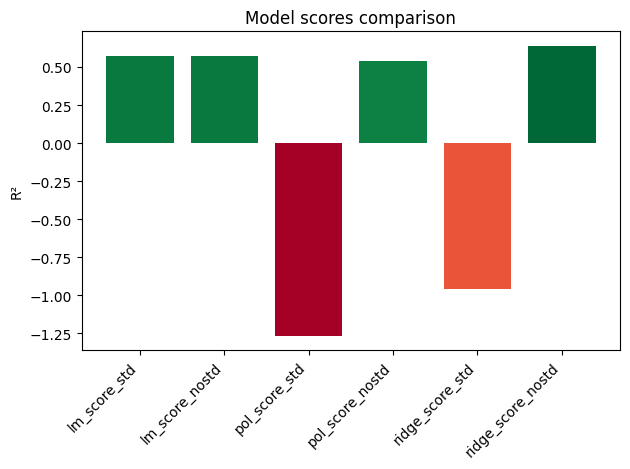

best model: ridge_score_nostd, with score = 0.6386105707361004
————————————————————
Test number 2 : test_size = 0.3
subtest 0
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.0183075853340363e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.482760422468086e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.442655875750357e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco

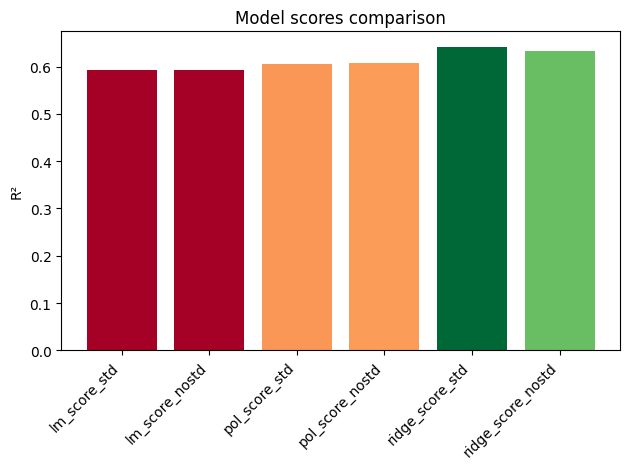

best model: ridge_score_std, with score = 0.6425754995818843
subtest 1
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9157566015090518e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3232395257376925e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3112581982892748e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

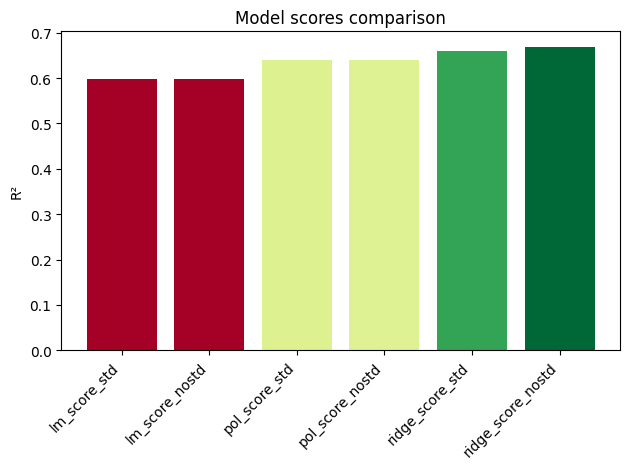

best model: ridge_score_nostd, with score = 0.6697193903537111
subtest 2
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.958045440030448e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9570982173120205e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.947729925252544e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco

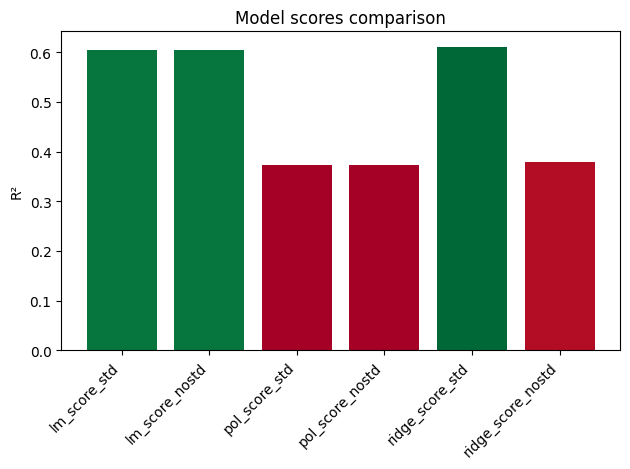

best model: ridge_score_std, with score = 0.6116181316349667
subtest 3
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.602542647213217e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5845651491261498e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5754570089191665e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

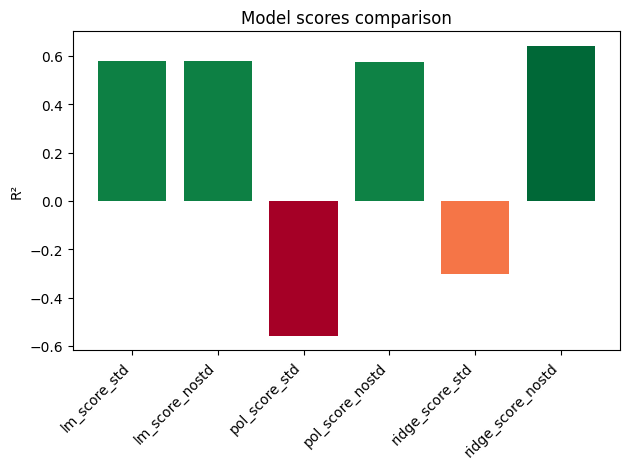

best model: ridge_score_nostd, with score = 0.641989130937179
————————————————————
with outliers inside 2.25*IQR
————————————————————
————————————————————
Test number 0 : test_size = 0.1
subtest 0
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.611450602440284e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3401372800803885e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.34075428906572e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcon

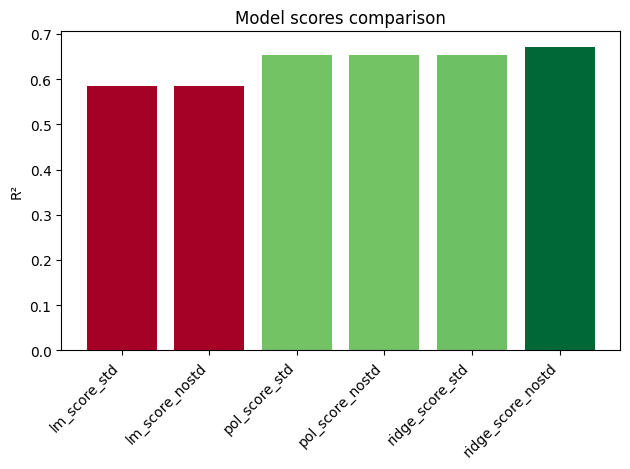

best model: ridge_score_nostd, with score = 0.6722847946661067
subtest 1
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.25340121325236e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2974101811709542e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.292282521114614e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcon

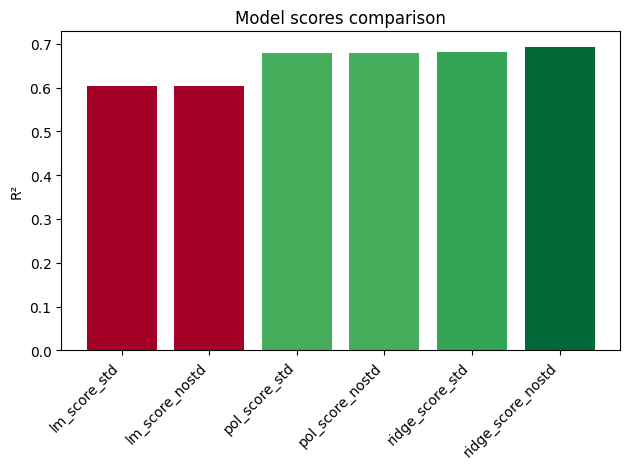

best model: ridge_score_nostd, with score = 0.694089841437715
subtest 2
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.078098235026256e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3244632271115919e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3098351272534672e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

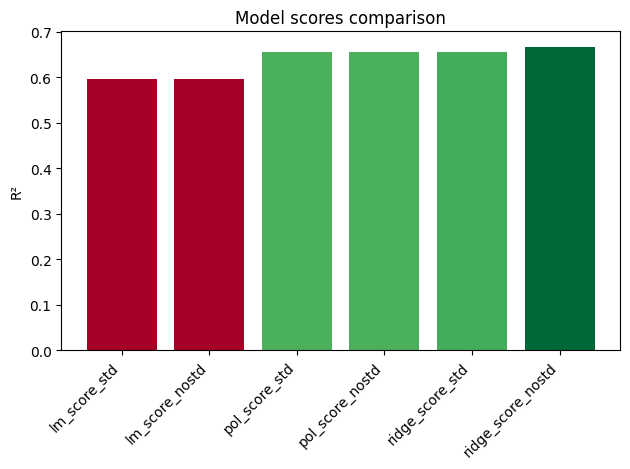

best model: ridge_score_nostd, with score = 0.6674684364168704
subtest 3
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.939326785988605e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.367318968352441e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3388122116953065e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco

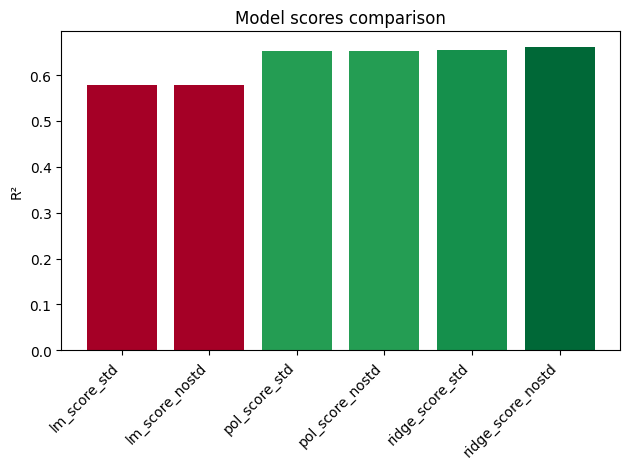

best model: ridge_score_nostd, with score = 0.6621575676833078
————————————————————
Test number 1 : test_size = 0.2
subtest 0
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.090784629021324e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3419068146283577e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3422776060125276e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

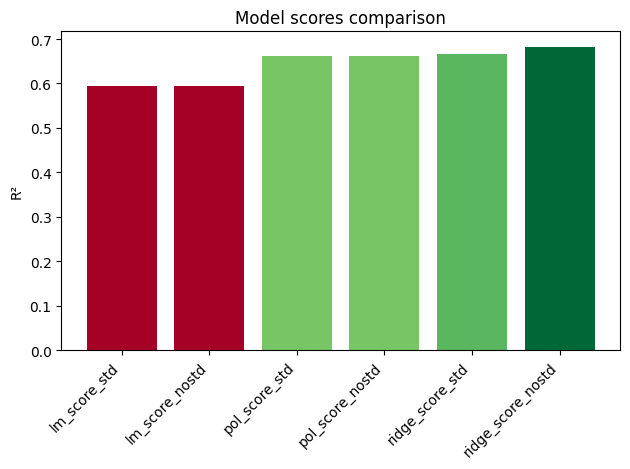

best model: ridge_score_nostd, with score = 0.683162264340541
subtest 1
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.027738846650381e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2983589040391812e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3201160628286854e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

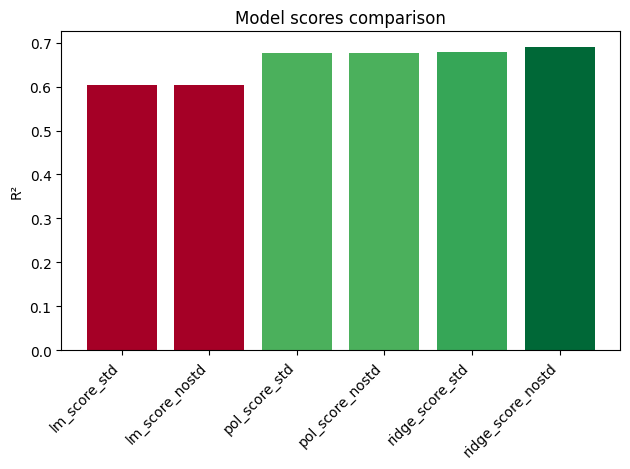

best model: ridge_score_nostd, with score = 0.6910622694392035
subtest 2
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6846044351650565e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3103914451575183e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3100592886988134e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

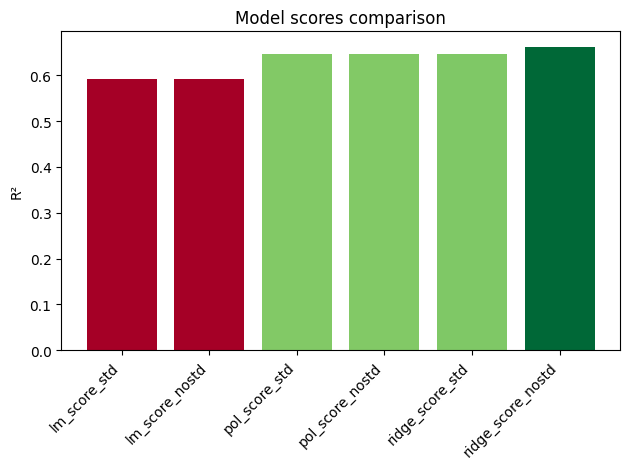

best model: ridge_score_nostd, with score = 0.6625499789958287
subtest 3
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3363765701243475e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.339927893138427e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3401429634532429e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

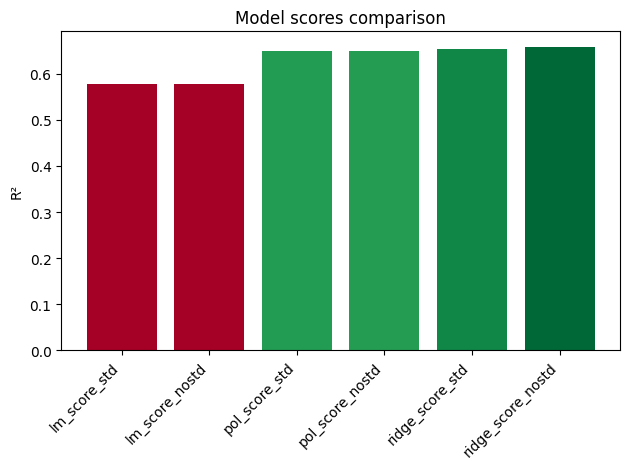

best model: ridge_score_nostd, with score = 0.6592312583843614
————————————————————
Test number 2 : test_size = 0.3
subtest 0
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.490878336299377e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.644634403103433e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6433414323502047e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco

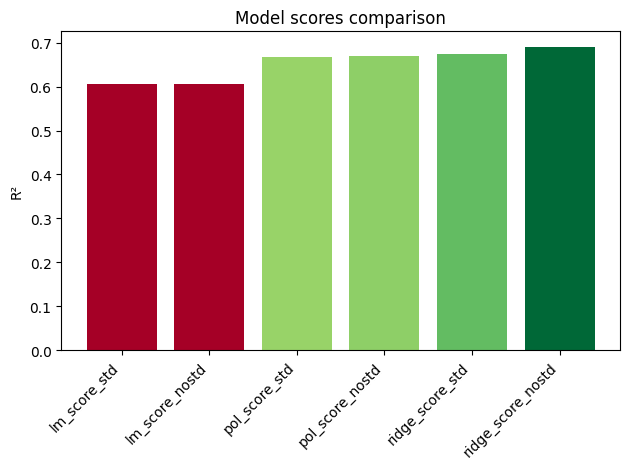

best model: ridge_score_nostd, with score = 0.6911570429810543
subtest 1
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.056782567667153e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.279651371274704e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.3675478800477843e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco

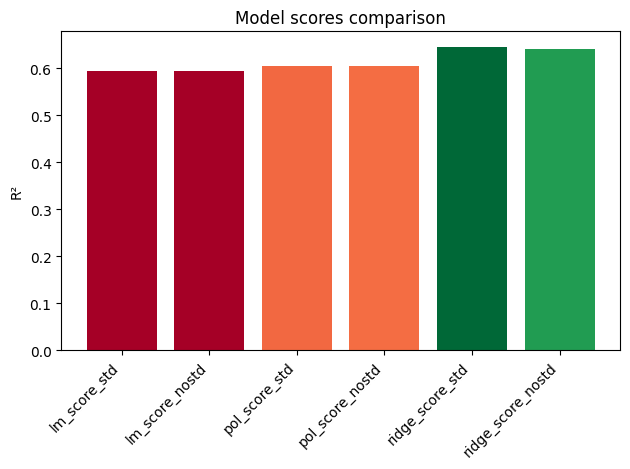

best model: ridge_score_std, with score = 0.6461042676229195
subtest 2
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3128050639489325e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3123036344647385e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3075583411911368e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

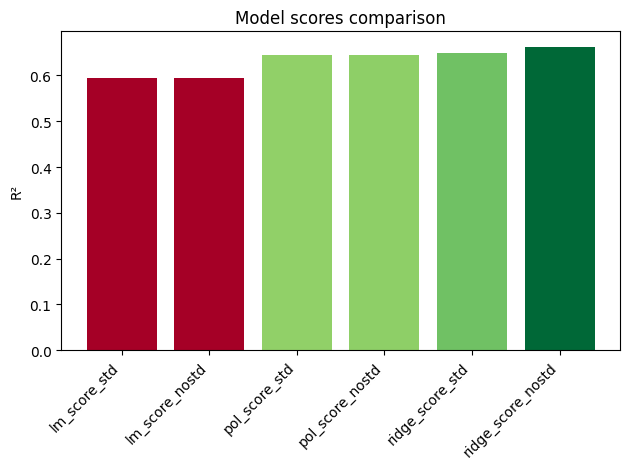

best model: ridge_score_nostd, with score = 0.6632418152864563
subtest 3
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3445938298743127e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3431409741648528e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3446590362683174e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

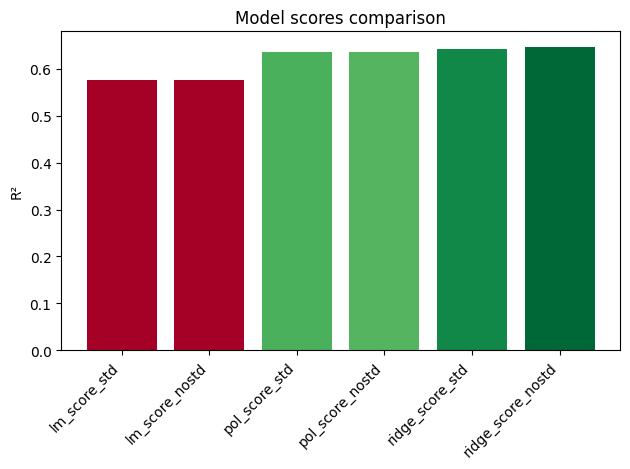

best model: ridge_score_nostd, with score = 0.6475626197097459
————————————————————
with outliers inside 3*IQR
————————————————————
————————————————————
Test number 0 : test_size = 0.1
subtest 0
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.611450602440284e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3401372800803885e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.34075428906572e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcon

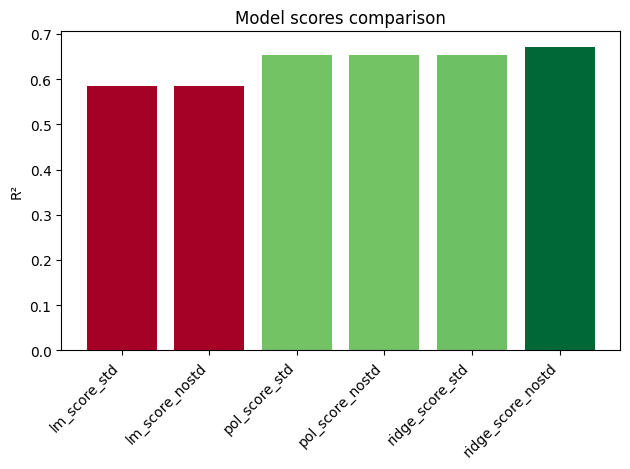

best model: ridge_score_nostd, with score = 0.6722847946661067
subtest 1
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.25340121325236e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2974101811709542e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.292282521114614e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcon

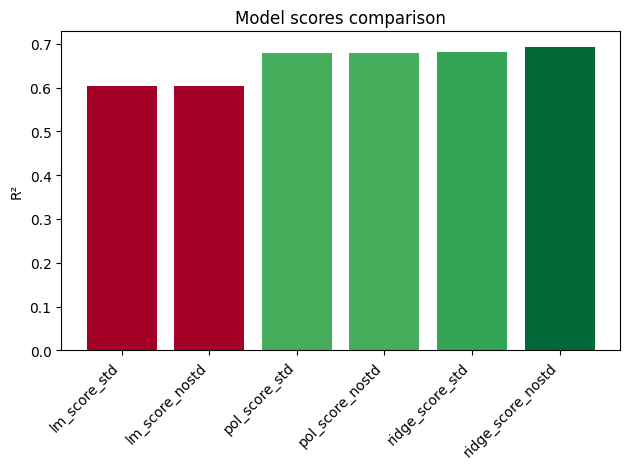

best model: ridge_score_nostd, with score = 0.694089841437715
subtest 2
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.078098235026256e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3244632271115919e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3098351272534672e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

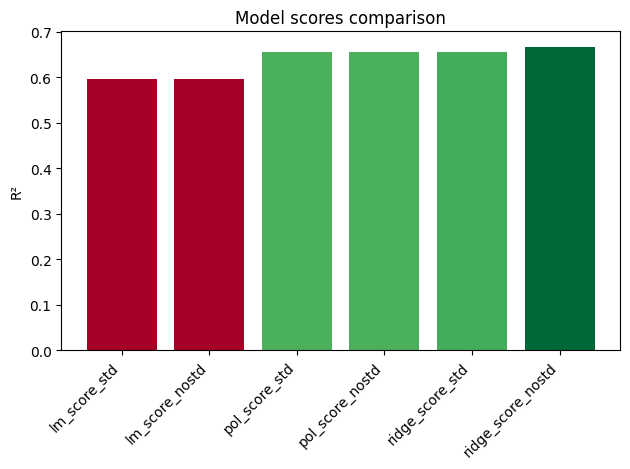

best model: ridge_score_nostd, with score = 0.6674684364168704
subtest 3
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.939326785988605e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.367318968352441e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3388122116953065e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco

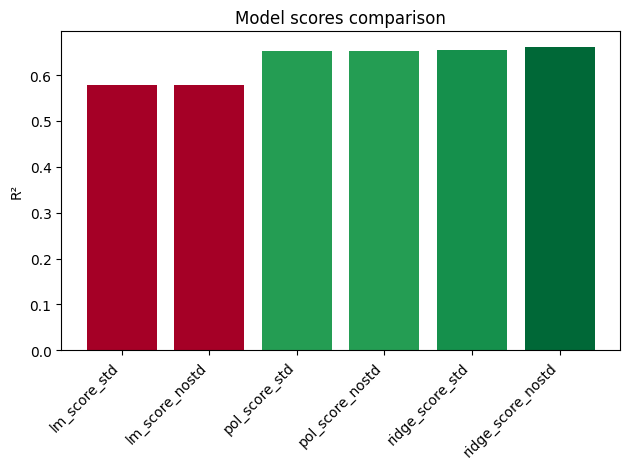

best model: ridge_score_nostd, with score = 0.6621575676833078
————————————————————
Test number 1 : test_size = 0.2
subtest 0
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.090784629021324e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3419068146283577e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3422776060125276e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

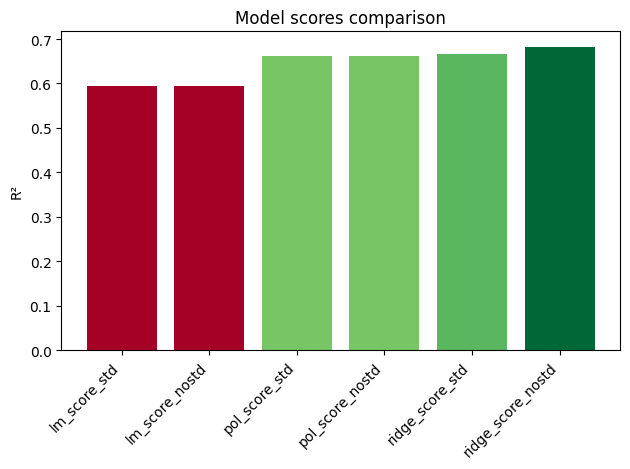

best model: ridge_score_nostd, with score = 0.683162264340541
subtest 1
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.027738846650381e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.2983589040391812e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3201160628286854e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

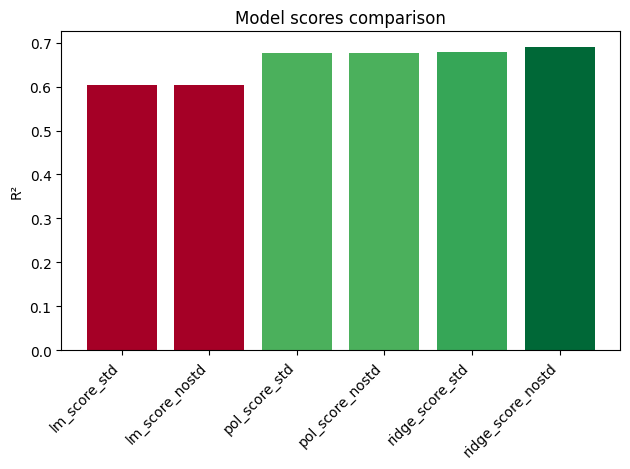

best model: ridge_score_nostd, with score = 0.6910622694392035
subtest 2
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.6846044351650565e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3103914451575183e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3100592886988134e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

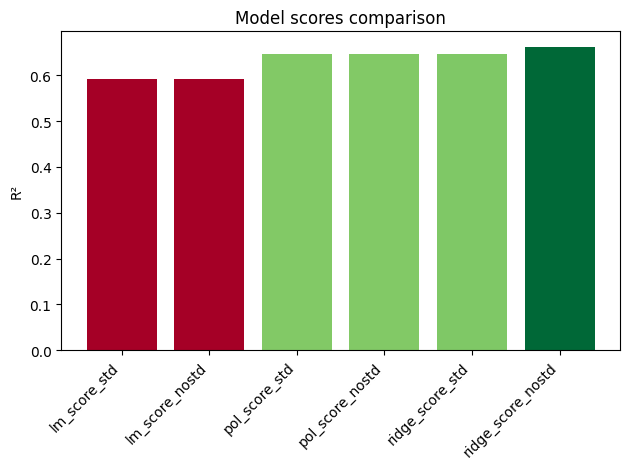

best model: ridge_score_nostd, with score = 0.6625499789958287
subtest 3
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3363765701243475e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.339927893138427e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3401429634532429e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rc

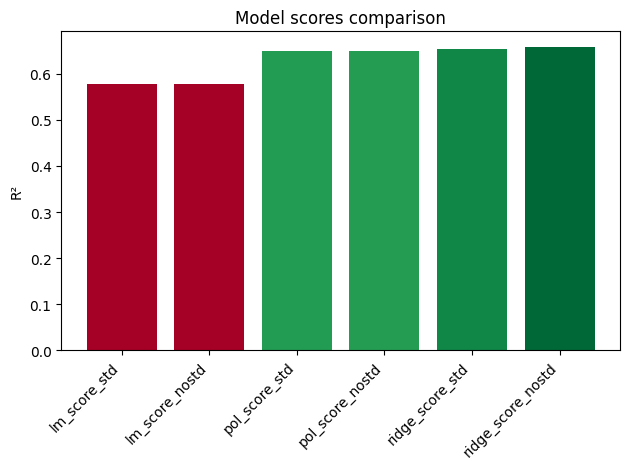

best model: ridge_score_nostd, with score = 0.6592312583843614
————————————————————
Test number 2 : test_size = 0.3
subtest 0
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.490878336299377e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.644634403103433e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6433414323502047e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco

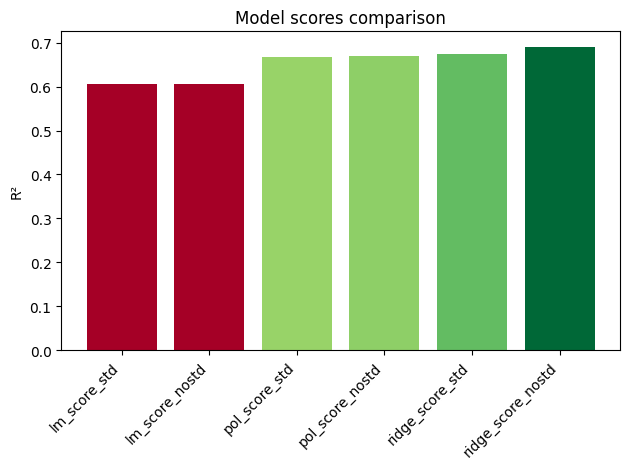

best model: ridge_score_nostd, with score = 0.6911570429810543
subtest 1
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.056782567667153e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.279651371274704e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.3675478800477843e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco

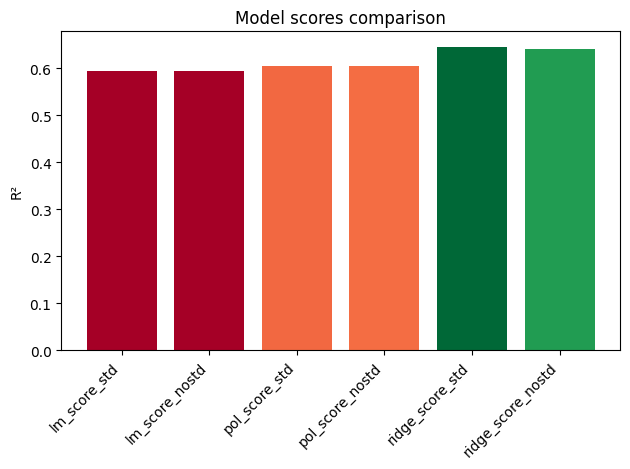

best model: ridge_score_std, with score = 0.6461042676229195
subtest 2
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3128050639489325e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3123036344647385e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3075583411911368e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

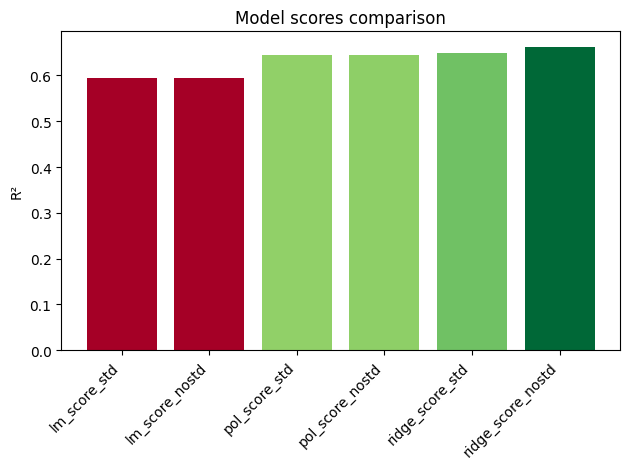

best model: ridge_score_nostd, with score = 0.6632418152864563
subtest 3
———————————————————— 

Data is OK


/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3445938298743127e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3431409741648528e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.3446590362683174e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/demuyncks/repos/immo-eliza/immo-eliza-env/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has r

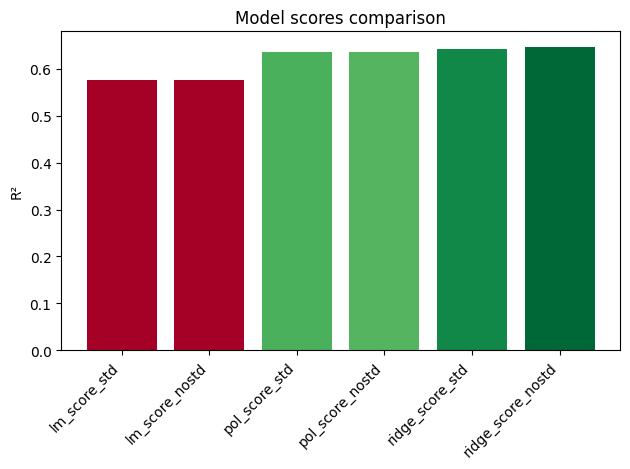

best model: ridge_score_nostd, with score = 0.6475626197097459


In [ ]:
random_states=[8,25,50,75]
test_sizes=[0.1,0.2,0.3]
# ———————————————————————
df=load_dataset("../../data/simon-data/properties-2b-located.csv")
df=clean_columns(df)
for rate in [1.5,2.25,3]:
    whisker=rate
    print('—'*20)
    print(f'with outliers inside {rate}*IQR')
    print('—'*20)

    df=clean_outliers(df,whisker=whisker)
    X,y=get_X_y(df)
    for i,test_size in enumerate(test_sizes):
        print('—'*20)
        print(f'Test number {i} : test_size = {test_size}')
        for j,random_state in enumerate(random_states):
            print(f'subtest {j}')
            print('—'*20, '\n')


            X_train,X_test,y_train,y_test=split_clean_data(X,y,random_state=random_state,test_size=test_size)
            get_all_models_score(X_train,X_test,y_train,y_test)

# Check with coach :
# Large variations from one subset to another, depending on distribution
# ==> Clean outliers ?


In [41]:
max(scores_dict.values).keys


NameError: name 'scores_dict' is not defined

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

NameError: name 'X_train' is not defined

In [73]:
df=load_dataset("../../data/simon-data/properties-2b-located.csv")
X,y=get_X_y(df)

In [19]:
y


0         369000
1         385000
2         135000
3         284000
4         299000
          ...   
12201     410000
12202     450000
12203     229000
12204     199000
12205    1090000
Name: price, Length: 11663, dtype: int64

In [47]:
pd.get_dummies(df).corr()['price']
df.dtypes

type_of_property              str
subtype_of_property           str
price                       int64
number_of_rooms           float64
living_area                 int64
fully_equipped_kitchen    float64
open_fire                   int64
terrace                     int64
garden                      int64
garden_area               float64
surface_of_the_land       float64
number_of_facades         float64
swimming_pool               int64
state_of_the_building     float64
province                      str
region                        str
dtype: object

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=3)

In [80]:
X

,number_of_rooms,living_area,open_fire,terrace,garden,garden_area,number_of_facades,swimming_pool,state_of_the_building,type_of_property_Apartment,...,province_Hainaut,province_Limburg,province_Liège,province_Luxembourg,province_Namur,province_Walloon Brabant,province_West Flanders,region_Brussels,region_Flemish Region,region_Walloon Region
0,3.0,378,0,1,1,0.0,2.0,0,0.0,False,...,False,False,False,False,False,False,False,False,True,False
1,2.0,100,0,1,0,0.0,2.0,0,1.0,True,...,False,False,False,False,False,False,False,True,False,False
2,3.0,125,0,0,1,0.0,2.0,0,1.0,False,...,True,False,False,False,False,False,False,False,False,True
3,3.0,180,0,0,1,240.0,2.0,0,0.0,False,...,False,False,False,False,False,False,False,False,True,False
4,4.0,124,0,1,1,0.0,3.0,0,4.0,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12202,3.0,170,0,0,1,0.0,3.0,0,4.0,False,...,False,False,False,False,False,False,False,False,True,False
12203,1.0,72,0,0,0,0.0,3.0,0,1.0,True,...,False,False,False,False,False,False,False,True,False,False
12204,3.0,134,1,1,1,0.0,2.0,0,1.0,False,...,True,False,False,False,False,False,False,False,False,True
12205,5.0,243,0,1,1,0.0,2.0,0,1.0,False,...,False,False,False,False,False,False,False,True,False,False


In [20]:
y

0         369000
1         385000
2         135000
3         284000
4         299000
          ...   
12201     410000
12202     450000
12203     229000
12204     199000
12205    1090000
Name: price, Length: 11663, dtype: int64